# IT549: Deep Learning
## Lab Assignment 4: Object Detection Evolution — From R-CNN to YOLO

**Dataset:** Fruit Images (Apple, Banana, Orange) — Kaggle  




In [1]:
# Install required libraries (run once)
!pip install opencv-python-headless matplotlib numpy --quiet

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Explore the downloaded dataset structure
dataset_root = "/content/drive/MyDrive/Dataset_Object_Detection"

for root, dirs, files_list in os.walk(dataset_root):
    level = root.replace(dataset_root, '').count(os.sep)
    indent = '│   ' * (level) + '├── '
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = '│   ' * (level + 1) + '├── '
        for f in files_list[:5]:  # Show first 5 files only
            print(f"{subindent}{f}")
        if len(files_list) > 5:
            print(f"{subindent}... and {len(files_list) - 5} more files")

├── Dataset_Object_Detection/
│   ├── test/
│   │   ├── apple_77.jpg
│   │   ├── apple_78.jpg
│   │   ├── apple_77.xml
│   │   ├── apple_91.xml
│   │   ├── banana_83.jpg
│   │   ├── ... and 115 more files
│   ├── train/
│   │   ├── apple_15.xml
│   │   ├── apple_11.xml
│   │   ├── apple_20.jpg
│   │   ├── apple_12.jpg
│   │   ├── apple_19.xml
│   │   ├── ... and 475 more files


In [5]:
import glob

# Find all image files
all_images = glob.glob(os.path.join(dataset_root, "**", "*.jpg"), recursive=True) + \
             glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True)

# Find all annotation files
all_annotations = glob.glob(os.path.join(dataset_root, "**", "*.xml"), recursive=True) + \
                  glob.glob(os.path.join(dataset_root, "**", "*.txt"), recursive=True)

print(f"📸 Total images found   : {len(all_images)}")
print(f"📝 Total annotations    : {len(all_annotations)}")
print(f"\nSample image path: {all_images[0] if all_images else 'None found'}")
print(f"Sample annotation : {all_annotations[0] if all_annotations else 'None found'}")

📸 Total images found   : 300
📝 Total annotations    : 300

Sample image path: /content/drive/MyDrive/Dataset_Object_Detection/test/apple_77.jpg
Sample annotation : /content/drive/MyDrive/Dataset_Object_Detection/test/apple_77.xml


---

## Preparation: Ground Truth Visualization

In object detection, **ground truth** refers to the manually labeled bounding boxes and class names in the dataset.

**Steps:**
1. Load a random image
2. Parse its annotation file (`.xml` for Pascal VOC format)
3. Draw bounding boxes + class labels using **OpenCV** and **Matplotlib**

The Fruit dataset uses **Pascal VOC XML format** with `<xmin>`, `<ymin>`, `<xmax>`, `<ymax>` coordinates.

In [6]:
import xml.etree.ElementTree as ET

def parse_xml_annotation(xml_path):
    """
    Parse a Pascal VOC XML annotation file.

    Args:
        xml_path (str): Path to the .xml annotation file.

    Returns:
        image_filename (str): The image filename referenced in the XML.
        boxes (list): List of dicts with keys: 'label', 'xmin', 'ymin', 'xmax', 'ymax'
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_filename = root.find("filename").text

    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))
        boxes.append({
            "label": label,
            "xmin": xmin, "ymin": ymin,
            "xmax": xmax, "ymax": ymax
        })

    return image_filename, boxes


# Filter only XML files for annotation parsing
xml_files = [f for f in all_annotations if f.endswith(".xml")]
print(f"📄 XML annotation files found: {len(xml_files)}")

if xml_files:
    sample_xml = xml_files[0]
    fname, bboxes = parse_xml_annotation(sample_xml)
    print(f"\nSample annotation parsed from: {sample_xml}")
    print(f"  Image filename : {fname}")
    print(f"  Bounding boxes :")
    for b in bboxes:
        print(f"    {b}")

📄 XML annotation files found: 300

Sample annotation parsed from: /content/drive/MyDrive/Dataset_Object_Detection/test/apple_77.xml
  Image filename : apple_77.jpg
  Bounding boxes :
    {'label': 'apple', 'xmin': 71, 'ymin': 60, 'xmax': 175, 'ymax': 164}
    {'label': 'apple', 'xmin': 12, 'ymin': 22, 'xmax': 105, 'ymax': 111}
    {'label': 'apple', 'xmin': 134, 'ymin': 23, 'xmax': 243, 'ymax': 115}
    {'label': 'apple', 'xmin': 107, 'ymin': 126, 'xmax': 216, 'ymax': 229}
    {'label': 'apple', 'xmin': 207, 'ymin': 138, 'xmax': 298, 'ymax': 229}


📄 Annotation file : /content/drive/MyDrive/Dataset_Object_Detection/test/orange_84.xml
🖼️  Image file      : /content/drive/MyDrive/Dataset_Object_Detection/test/orange_84.jpg
📦 Ground truth boxes (1 total):
   [ORANGE]  (145, 36) → (421, 286)



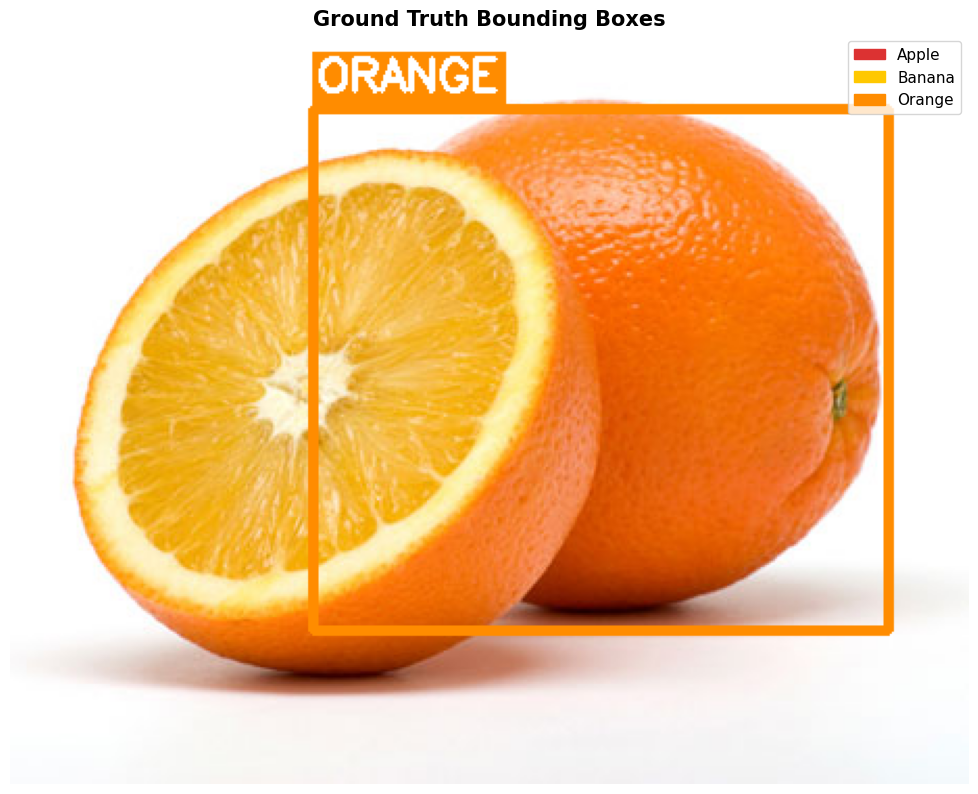

✅ Visualization saved as 'ground_truth_visualization.png'


In [7]:
# Class-to-color mapping for visual clarity
CLASS_COLORS = {
    "apple":  (220,  50,  50),   # Red
    "banana": (255, 200,   0),   # Yellow
    "orange": (255, 140,   0),   # Orange
}
DEFAULT_COLOR = (100, 200, 100)   # Green fallback

def draw_bounding_boxes(image_path, boxes):
    """
    Draw ground truth bounding boxes on an image using OpenCV,
    then display using Matplotlib.

    Args:
        image_path (str): Path to the image file.
        boxes (list): List of dicts with 'label', 'xmin', 'ymin', 'xmax', 'ymax'.
    """
    # Load image with OpenCV (BGR format)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Could not load image: {image_path}")
        return

    # Convert BGR → RGB for Matplotlib display
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Draw each bounding box
    for box in boxes:
        label = box["label"].lower()
        color = CLASS_COLORS.get(label, DEFAULT_COLOR)

        x1, y1, x2, y2 = box["xmin"], box["ymin"], box["xmax"], box["ymax"]

        # Draw rectangle (thickness=3)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness=3)

        # Draw label background
        (text_w, text_h), baseline = cv2.getTextSize(
            label.upper(), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2
        )
        cv2.rectangle(img_rgb,
                      (x1, y1 - text_h - baseline - 4),
                      (x1 + text_w + 4, y1),
                      color, thickness=-1)

        # Draw label text (white)
        cv2.putText(img_rgb, label.upper(),
                    (x1 + 2, y1 - baseline - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Display with Matplotlib
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)
    ax.set_title("Ground Truth Bounding Boxes", fontsize=15, fontweight='bold')
    ax.axis("off")

    # Add legend
    legend_handles = [
        patches.Patch(color=np.array(c)/255, label=cls.capitalize())
        for cls, c in CLASS_COLORS.items()
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=11)

    plt.tight_layout()
    plt.savefig("ground_truth_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualization saved as 'ground_truth_visualization.png'")


# ── Pick a random XML annotation and visualize ───────────────────────────────
random.seed(42)
random_xml = random.choice(xml_files)
img_filename, gt_boxes = parse_xml_annotation(random_xml)

# Locate the matching image file
xml_dir = os.path.dirname(random_xml)
img_path = os.path.join(xml_dir, img_filename)

# Fallback: search by filename if not found in same folder
if not os.path.exists(img_path):
    matches = [p for p in all_images if os.path.basename(p) == img_filename]
    img_path = matches[0] if matches else None

print(f"📄 Annotation file : {random_xml}")
print(f"🖼️  Image file      : {img_path}")
print(f"📦 Ground truth boxes ({len(gt_boxes)} total):")
for b in gt_boxes:
    print(f"   [{b['label'].upper()}]  ({b['xmin']}, {b['ymin']}) → ({b['xmax']}, {b['ymax']})")

print()
draw_bounding_boxes(img_path, gt_boxes)

---

## Task 1: Intersection over Union (IoU)

**IoU** is the fundamental metric in object detection. It measures how well a predicted bounding box overlaps with the ground truth box.

$$
\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}
$$

| IoU Range | Meaning |
|-----------|---------|
| 1.0 | Perfect overlap |
| > 0.5 | Generally considered a "good" detection |
| 0.0 | No overlap at all |

**Box format used:** `[x_min, y_min, x_max, y_max]`

We implement this **from scratch** using pure Python + NumPy — no libraries like torchvision.

In [8]:
def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.

    Args:
        box1 (list or tuple): [x_min, y_min, x_max, y_max]
        box2 (list or tuple): [x_min, y_min, x_max, y_max]

    Returns:
        float: IoU score in range [0.0, 1.0]
    """
    # Step 1: Unpack coordinates
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    # Step 2: Compute intersection rectangle
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    # Step 3: Intersection area (0 if no overlap)
    inter_width  = max(0, inter_x_max - inter_x_min)
    inter_height = max(0, inter_y_max - inter_y_min)
    intersection_area = inter_width * inter_height

    # Step 4: Individual box areas
    area_box1 = (x1_max - x1_min) * (y1_max - y1_min)
    area_box2 = (x2_max - x2_min) * (y2_max - y2_min)

    # Step 5: Union area
    union_area = area_box1 + area_box2 - intersection_area

    # Step 6: IoU
    if union_area == 0:
        return 0.0  # Avoid division by zero

    iou = intersection_area / union_area
    return round(iou, 4)


print("✅ IoU function defined successfully!")

✅ IoU function defined successfully!


In [9]:
# Define three demonstration cases

test_cases = [
    {
        "description": "Case 1 — High Overlap (nearly identical boxes)",
        "box1": [50, 50, 200, 200],
        "box2": [60, 60, 210, 210],
        "expected": "Close to 1.0"
    },
    {
        "description": "Case 2 — Partial Overlap (boxes share a region)",
        "box1": [0, 0, 100, 100],
        "box2": [50, 50, 150, 150],
        "expected": "Around 0.14"
    },
    {
        "description": "Case 3 — No Overlap (completely disjoint boxes)",
        "box1": [0, 0,  50,  50],
        "box2": [100, 100, 200, 200],
        "expected": "Exactly 0.0"
    },
]

# Print results
print("=" * 60)
print("       IoU DEMONSTRATION — THREE TEST CASES")
print("=" * 60)

for case in test_cases:
    iou_score = compute_iou(case["box1"], case["box2"])
    print(f"\n📌 {case['description']}")
    print(f"   Box 1 : {case['box1']}")
    print(f"   Box 2 : {case['box2']}")
    print(f"   IoU   : {iou_score}  (expected: {case['expected']})")

print("\n" + "=" * 60)

       IoU DEMONSTRATION — THREE TEST CASES

📌 Case 1 — High Overlap (nearly identical boxes)
   Box 1 : [50, 50, 200, 200]
   Box 2 : [60, 60, 210, 210]
   IoU   : 0.7717  (expected: Close to 1.0)

📌 Case 2 — Partial Overlap (boxes share a region)
   Box 1 : [0, 0, 100, 100]
   Box 2 : [50, 50, 150, 150]
   IoU   : 0.1429  (expected: Around 0.14)

📌 Case 3 — No Overlap (completely disjoint boxes)
   Box 1 : [0, 0, 50, 50]
   Box 2 : [100, 100, 200, 200]
   IoU   : 0.0  (expected: Exactly 0.0)



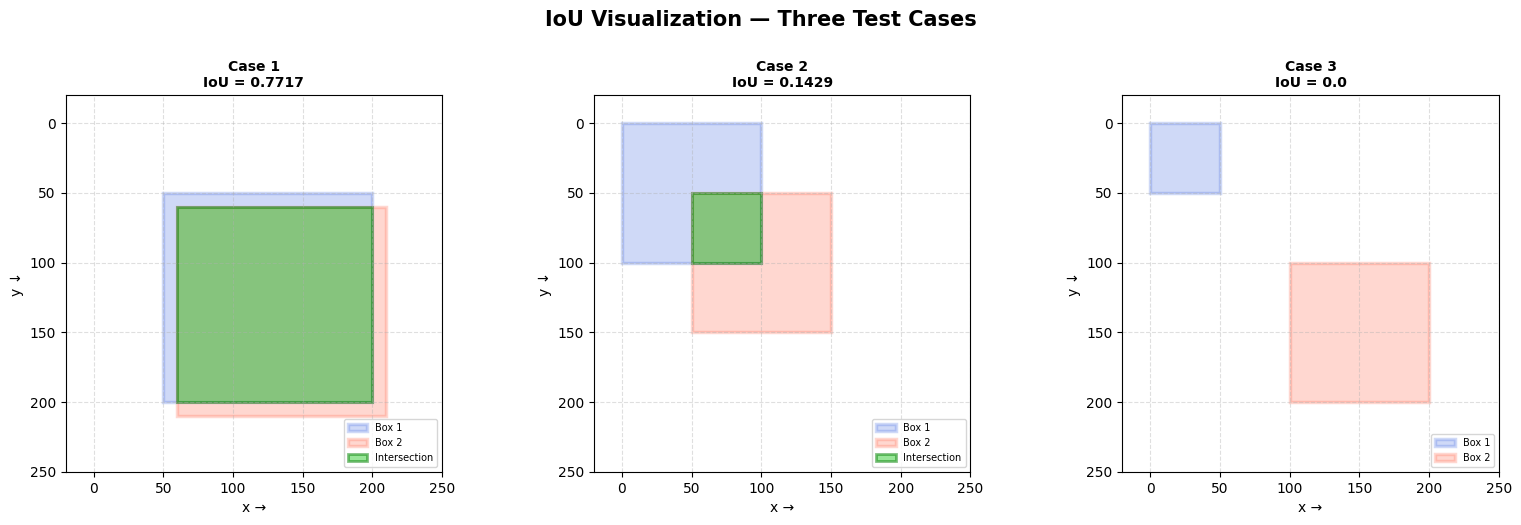

✅ IoU visualization saved as 'iou_visualization.png'


In [10]:
def visualize_iou_cases(test_cases):
    """
    Plot all IoU test cases side by side showing both boxes
    and highlighting the intersection region.
    """
    fig, axes = plt.subplots(1, len(test_cases), figsize=(16, 5))
    fig.suptitle("IoU Visualization — Three Test Cases", fontsize=15, fontweight='bold', y=1.02)

    for ax, case in zip(axes, test_cases):
        b1 = case["box1"]
        b2 = case["box2"]
        iou_score = compute_iou(b1, b2)

        # Compute intersection
        ix_min = max(b1[0], b2[0])
        iy_min = max(b1[1], b2[1])
        ix_max = min(b1[2], b2[2])
        iy_max = min(b1[3], b2[3])
        has_intersection = ix_max > ix_min and iy_max > iy_min

        ax.set_xlim(-20, 250)
        ax.set_ylim(-20, 250)
        ax.set_aspect('equal')
        ax.invert_yaxis()  # Match image coordinate system (y down)

        # Draw box1
        rect1 = patches.Rectangle(
            (b1[0], b1[1]), b1[2]-b1[0], b1[3]-b1[1],
            linewidth=2.5, edgecolor='royalblue', facecolor='royalblue', alpha=0.25,
            label='Box 1'
        )
        ax.add_patch(rect1)

        # Draw box2
        rect2 = patches.Rectangle(
            (b2[0], b2[1]), b2[2]-b2[0], b2[3]-b2[1],
            linewidth=2.5, edgecolor='tomato', facecolor='tomato', alpha=0.25,
            label='Box 2'
        )
        ax.add_patch(rect2)

        # Draw intersection (if any)
        if has_intersection:
            rect_inter = patches.Rectangle(
                (ix_min, iy_min), ix_max-ix_min, iy_max-iy_min,
                linewidth=2, edgecolor='green', facecolor='limegreen', alpha=0.5,
                label='Intersection'
            )
            ax.add_patch(rect_inter)

        ax.set_title(
            f"{case['description'].split('—')[0].strip()}\n"
            f"IoU = {iou_score}",
            fontsize=10, fontweight='bold'
        )
        ax.legend(loc='lower right', fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xlabel("x →")
        ax.set_ylabel("y ↓")

    plt.tight_layout()
    plt.savefig("iou_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ IoU visualization saved as 'iou_visualization.png'")


visualize_iou_cases(test_cases)

---

## Task 2: The Baseline — Selective Search (R-CNN Step 1)

**Selective Search** is the region proposal algorithm used in the original R-CNN paper.
Instead of sliding a window across every possible location, Selective Search uses
image segmentation cues (color, texture, size, shape) to propose candidate regions
that are likely to contain objects.

### How it works:
1. Over-segments the image into small regions
2. Merges similar regions bottom-up
3. Returns bounding boxes around merged regions as **proposals**

> In R-CNN, these ~2000 proposals are each cropped and passed through a CNN separately.
> We extract only the **top 200** proposals for visualization.

✅ Image loaded: /content/drive/MyDrive/Dataset_Object_Detection/train/banana_40.jpg
   Shape: (420, 634, 3)  (H x W x C)


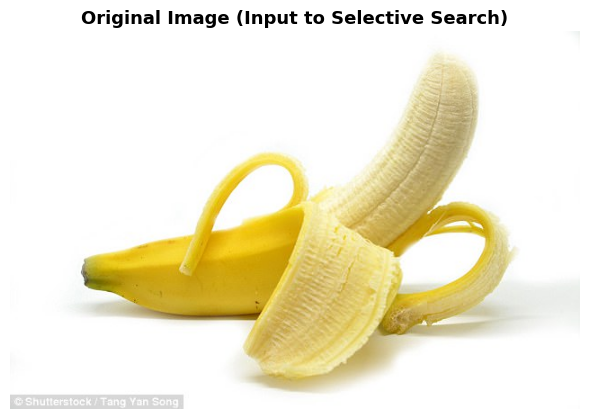

In [12]:
# Pick a random image
random.seed(7)
img_path = random.choice(all_images)

# Load with OpenCV (BGR) and convert to RGB
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"✅ Image loaded: {img_path}")
print(f"   Shape: {img_rgb.shape}  (H x W x C)")

# Show the original image
plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title("Original Image (Input to Selective Search)", fontsize=13, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# ── Initialize OpenCV Selective Search ───────────────────────────────────────
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

# Set the input image
ss.setBaseImage(img_bgr)

# Use 'Fast' mode — good balance of speed vs quality
# Switch to ss.switchToSelectiveSearchQuality() for more proposals (slower)
ss.switchToSelectiveSearchFast()

# Run selective search — returns list of (x, y, w, h) proposals
print("⏳ Running Selective Search... (this may take a few seconds)")
proposals = ss.process()

print(f"✅ Total proposals generated : {len(proposals)}")

# Keep only the top 200
top_200 = proposals[:200]

print(f"📦 Using top 200 proposals")
print(f"\nSample proposals (x, y, w, h):")
for i, (x, y, w, h) in enumerate(top_200[:5]):
    print(f"  Proposal {i+1}: x={x}, y={y}, w={w}, h={h}")

⏳ Running Selective Search... (this may take a few seconds)
✅ Total proposals generated : 655
📦 Using top 200 proposals

Sample proposals (x, y, w, h):
  Proposal 1: x=447, y=94, w=28, h=32
  Proposal 2: x=374, y=314, w=95, h=43
  Proposal 3: x=482, y=212, w=34, h=7
  Proposal 4: x=83, y=276, w=42, h=13
  Proposal 5: x=0, y=404, w=192, h=16


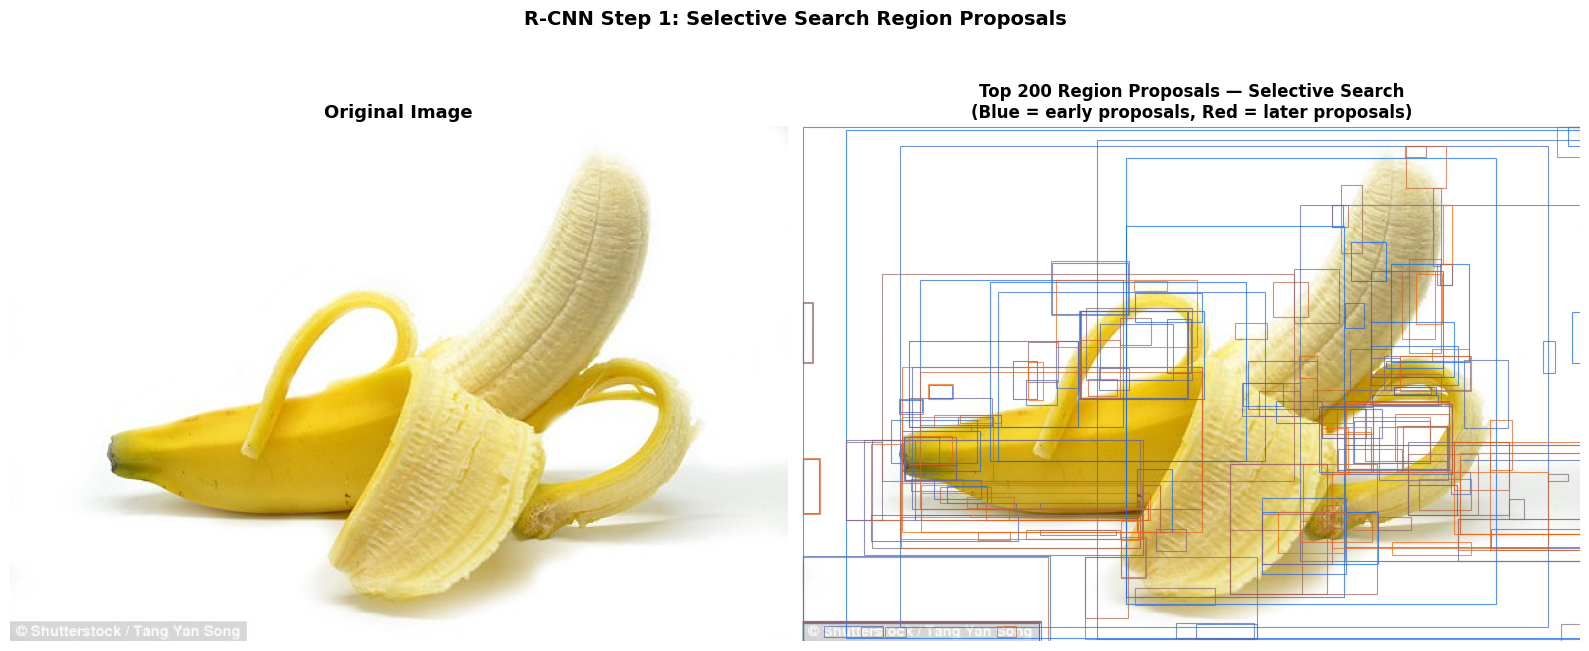

✅ Visualization saved as 'task2_selective_search_proposals.png'


In [14]:
def visualize_proposals(img_rgb, proposals, n=200):
    """
    Draw the top-n region proposals on the image.

    Args:
        img_rgb   : Image in RGB format (H x W x 3)
        proposals : List of (x, y, w, h) bounding boxes
        n         : Number of proposals to draw
    """
    img_copy = img_rgb.copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
    axes[0].axis("off")

    # Right: Image with proposals
    axes[1].imshow(img_copy)

    for i, (x, y, w, h) in enumerate(proposals[:n]):
        # Use a color gradient: early proposals in blue, later in red
        ratio = i / n
        color = (ratio, 0.4, 1 - ratio)   # RGB tuple (0-1 range for Matplotlib)

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=0.8,
            edgecolor=color,
            facecolor='none',
            alpha=0.7
        )
        axes[1].add_patch(rect)

    axes[1].set_title(
        f"Top {n} Region Proposals — Selective Search\n"
        f"(Blue = early proposals, Red = later proposals)",
        fontsize=12, fontweight='bold'
    )
    axes[1].axis("off")

    plt.suptitle(
        "R-CNN Step 1: Selective Search Region Proposals",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("task2_selective_search_proposals.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualization saved as 'task2_selective_search_proposals.png'")


visualize_proposals(img_rgb, top_200, n=200)

📊 Proposal Statistics (Top 200):
   Width  — Min:    6  Max:  634  Avg: 79.3
   Height — Min:    1  Max:  420  Avg: 48.9
   Area   — Min:    102  Max: 266280  Avg: 8909


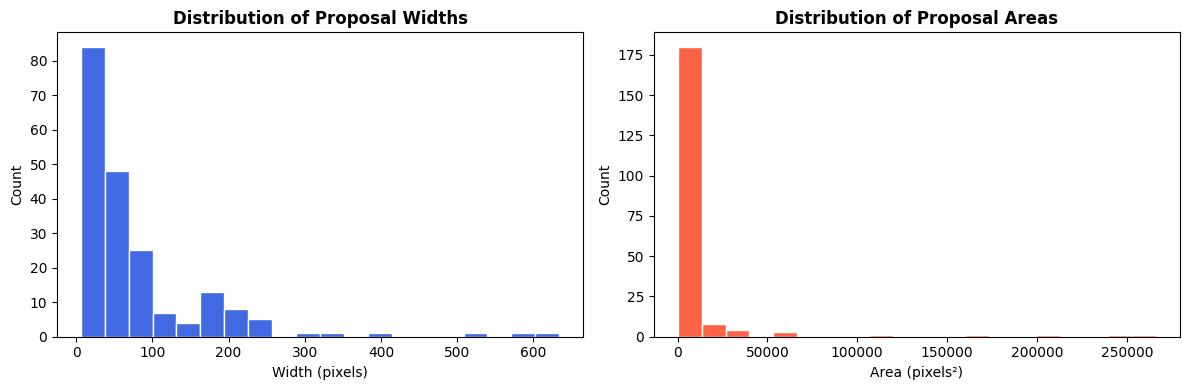

✅ Statistics plot saved as 'task2_proposal_stats.png'


In [15]:
# Analyze the size distribution of the top 200 proposals
widths  = [w for (x, y, w, h) in top_200]
heights = [h for (x, y, w, h) in top_200]
areas   = [w * h for (x, y, w, h) in top_200]

print("📊 Proposal Statistics (Top 200):")
print(f"   Width  — Min: {min(widths):>4}  Max: {max(widths):>4}  Avg: {np.mean(widths):.1f}")
print(f"   Height — Min: {min(heights):>4}  Max: {max(heights):>4}  Avg: {np.mean(heights):.1f}")
print(f"   Area   — Min: {min(areas):>6}  Max: {max(areas):>6}  Avg: {np.mean(areas):.0f}")

# Plot size distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=20, color='royalblue', edgecolor='white')
axes[0].set_title("Distribution of Proposal Widths", fontweight='bold')
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Count")

axes[1].hist(areas, bins=20, color='tomato', edgecolor='white')
axes[1].set_title("Distribution of Proposal Areas", fontweight='bold')
axes[1].set_xlabel("Area (pixels²)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("task2_proposal_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Statistics plot saved as 'task2_proposal_stats.png'")

### Task 2 — Summary

| Item | Value |
|------|-------|
| Algorithm | OpenCV `SelectiveSearchSegmentation` (Fast mode) |
| Total proposals generated | ~1000–2000 (varies per image) |
| Proposals visualized | Top 200 |
| Proposal format | `(x, y, w, h)` → top-left corner + width/height |

**Key Observation:**
Selective Search generates proposals of **varying sizes** — small boxes for small objects
and large boxes for larger regions. This is one of its strengths over fixed sliding windows.

**The R-CNN Bottleneck (preview for Task 3):**
Each of these 200 proposals will need to be:
1. **Cropped** from the image
2. **Resized** to 224×224
3. **Passed through a CNN** independently

→ That's 200 separate forward passes through a deep network — which is very slow!
We'll measure exactly how slow in Task 3.

---

## Task 3: The R-CNN Bottleneck — Independent Crop + CNN per Proposal

In the original **R-CNN**, every single region proposal is:
1. **Cropped** from the original image
2. **Resized** to 224×224
3. **Passed independently through a CNN** to extract a feature vector

This means if Selective Search gives 100 proposals → **100 separate CNN forward passes**.

### What we do here:
- Load **ResNet18** (pre-trained) and remove its final classification layer
- Loop through the **top 100 proposals** from Task 2
- Crop → Resize → CNN forward pass for each
- **Record total execution time** to expose the bottleneck

In [16]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import time

# Load pre-trained ResNet18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final fully connected layer (classifier)
# Original: ResNet18 → avgpool → fc (1000 classes)
# We keep everything UP TO avgpool → outputs 512-dim feature vector
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor.eval()  # Set to inference mode

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device)

print(f"✅ ResNet18 loaded with final FC layer removed")
print(f"   Running on : {device}")
print(f"   Output     : 512-dimensional feature vector per crop")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


✅ ResNet18 loaded with final FC layer removed
   Running on : cuda
   Output     : 512-dimensional feature vector per crop


In [17]:
# Preprocessing transform for each crop
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

# Use top 100 proposals from Task 2
top_100 = proposals[:100]

# R-CNN Style Loop
print("⏳ Running R-CNN style inference on 100 proposals...")
print("   (crop → resize → CNN forward pass) × 100\n")

all_features = []
img_h, img_w = img_rgb.shape[:2]

start_time = time.time()  # ⏱️ Start timer

for i, (x, y, w, h) in enumerate(top_100):

    # Step 1: Clamp box to image boundaries
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(img_w, x + w)
    y2 = min(img_h, y + h)

    # Skip degenerate boxes
    if x2 <= x1 or y2 <= y1:
        continue

    # Step 2: Crop the region from the original image
    crop = img_rgb[y1:y2, x1:x2]

    # Step 3: Resize to 224×224 & convert to tensor
    crop_tensor = transform(crop).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

    # Step 4: Forward pass through ResNet18 (no gradient needed)
    with torch.no_grad():
        feature_vector = feature_extractor(crop_tensor)    # Shape: (1, 512, 1, 1)

    all_features.append(feature_vector.squeeze().cpu())

end_time = time.time()  # ⏱️ Stop timer

# Report results
rcnn_time = end_time - start_time

print(f"✅ Processed {len(all_features)} crops successfully")
print(f"\n{'='*45}")
print(f"  ⏱️  R-CNN Total Execution Time : {rcnn_time:.4f} seconds")
print(f"  ⏱️  Avg Time per Crop          : {rcnn_time/len(all_features)*1000:.2f} ms")
print(f"{'='*45}")
print(f"\n   Feature vector shape : {all_features[0].shape}")
print(f"   Total feature matrix : {len(all_features)} × {all_features[0].shape[0]}")

⏳ Running R-CNN style inference on 100 proposals...
   (crop → resize → CNN forward pass) × 100

✅ Processed 100 crops successfully

  ⏱️  R-CNN Total Execution Time : 1.4852 seconds
  ⏱️  Avg Time per Crop          : 14.85 ms

   Feature vector shape : torch.Size([512])
   Total feature matrix : 100 × 512


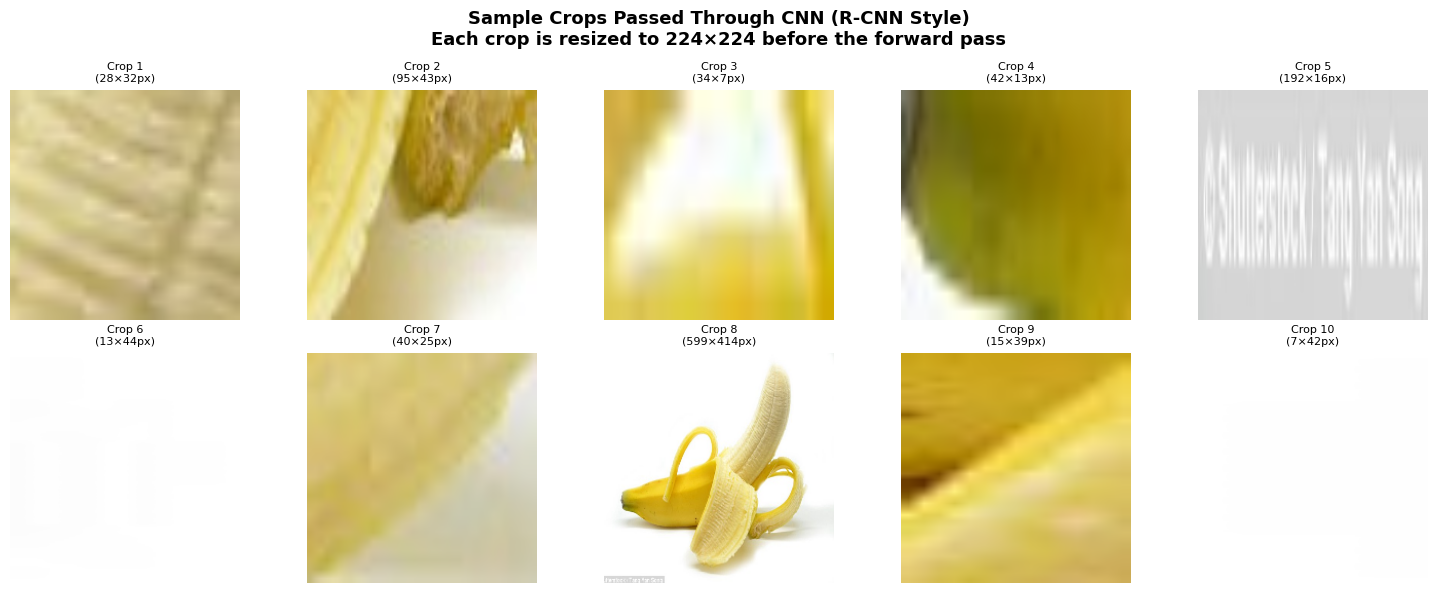

✅ Sample crops saved as 'task3_sample_crops.png'


In [18]:
# Show a sample of the cropped regions to understand what R-CNN processes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Crops Passed Through CNN (R-CNN Style)\n"
             "Each crop is resized to 224×224 before the forward pass",
             fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    x, y, w, h = top_100[idx]
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(img_w, x+w), min(img_h, y+h)
    crop = img_rgb[y1:y2, x1:x2]

    # Resize for display
    crop_display = cv2.resize(crop, (224, 224))

    ax.imshow(crop_display)
    ax.set_title(f"Crop {idx+1}\n({w}×{h}px)", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("task3_sample_crops.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample crops saved as 'task3_sample_crops.png'")

### Task 3 — Analysis: The R-CNN Bottleneck

| Metric | Value |
|--------|-------|
| Number of proposals processed | 100 |
| CNN used | ResNet18 (final FC removed) |
| Output per crop | 512-dim feature vector |
| **Total time** | 1.4852s |
| **Avg time per crop** | 14.85ms |

### Why is this slow?

The fundamental problem is **redundant computation**.

Every proposal region overlaps with other proposals — they share pixels.
Yet R-CNN **re-processes shared pixels over and over again**, once per crop.

For example:
- A large box covering the whole fruit and a smaller box inside it
  share most of their pixels
- R-CNN runs **two full CNN forward passes** on nearly identical data

### The key bottleneck:
> **100 proposals = 100 CNN forward passes**  
> If Selective Search returns 2000 proposals (as in the original paper),  
> that means **2000 full CNN forward passes per image** — making R-CNN  
> impractically slow for real-world use.

**Task 4 (Fast R-CNN)** solves this by passing the image through the CNN
**only once** and extracting features for all proposals from a single feature map.

---

## Task 4: Fast R-CNN — RoI Pooling on a Single Feature Map

**Fast R-CNN** solved the R-CNN bottleneck with one key insight:

> Instead of cropping the image and running CNN on each crop separately,
> pass the **entire image through CNN once** to get a feature map,
> then extract features for each proposal directly from that feature map
> using **RoI (Region of Interest) Pooling**.

### R-CNN vs Fast R-CNN:

| Step | R-CNN | Fast R-CNN |
|------|-------|------------|
| CNN forward passes | 100 (one per crop) | **1 (whole image)** |
| Feature extraction | Per crop | RoI Pool from shared feature map |
| Speed | Slow ❌ | Much faster ✅ |

In [19]:
import torchvision.ops as ops

# Extract only the convolutional backbone of ResNet18
# ResNet18 children: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc
# We take everything up to layer4 (index 0-7) — this gives us the spatial feature map

conv_backbone = torch.nn.Sequential(*list(resnet18.children())[:8])
conv_backbone.eval()
conv_backbone = conv_backbone.to(device)

# Preprocess the full image
full_image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = full_image_transform(img_rgb).unsqueeze(0).to(device)  # (1, 3, 224, 224)

# Single CNN forward pass on full image
with torch.no_grad():
    feature_map = conv_backbone(img_tensor)   # Shape: (1, 512, 7, 7)

print(f"✅ Full image passed through ResNet18 conv layers")
print(f"   Input image tensor  : {img_tensor.shape}   (B, C, H, W)")
print(f"   Output feature map  : {feature_map.shape}  (B, C, H, W)")

✅ Full image passed through ResNet18 conv layers
   Input image tensor  : torch.Size([1, 3, 224, 224])   (B, C, H, W)
   Output feature map  : torch.Size([1, 512, 7, 7])  (B, C, H, W)


In [20]:
# ── Calculate spatial scale (stride)
# Spatial scale = feature_map_size / input_image_size
# If 224×224 input → 7×7 feature map, stride = 7/224 = 1/32

input_h = img_tensor.shape[2]   # 224
input_w = img_tensor.shape[3]   # 224
feat_h  = feature_map.shape[2]  # 7
feat_w  = feature_map.shape[3]  # 7

spatial_scale = feat_h / input_h

print(f"📐 Spatial Scale Calculation:")
print(f"   Input size      : {input_h} × {input_w}")
print(f"   Feature map size: {feat_h} × {feat_w}")
print(f"   Spatial scale   : {feat_h}/{input_h} = {spatial_scale:.6f}  (≈ 1/32)")

📐 Spatial Scale Calculation:
   Input size      : 224 × 224
   Feature map size: 7 × 7
   Spatial scale   : 7/224 = 0.031250  (≈ 1/32)


In [21]:
# Convert proposals to RoI tensor format
# torchvision roi_pool expects boxes in (batch_idx, x1, y1, x2, y2) format
# Our proposals are in (x, y, w, h) — convert to (x1, y1, x2, y2)
# Also scale boxes to match the resized 224×224 input

orig_h, orig_w = img_rgb.shape[:2]
scale_x = 224 / orig_w
scale_y = 224 / orig_h

roi_boxes = []
for (x, y, w, h) in top_100:
    x1 = x * scale_x
    y1 = y * scale_y
    x2 = (x + w) * scale_x
    y2 = (y + h) * scale_y
    roi_boxes.append([0, x1, y1, x2, y2])  # 0 = batch index

roi_tensor = torch.tensor(roi_boxes, dtype=torch.float32).to(device)

print(f"✅ RoI tensor prepared")
print(f"   Shape : {roi_tensor.shape}  (num_rois, 5)")
print(f"   Format: [batch_idx, x1, y1, x2, y2]")
print(f"\nSample RoIs (first 3):")
for i in range(3):
    print(f"   RoI {i+1}: {roi_tensor[i].cpu().numpy().round(2)}")

# RoI Pooling
output_size = (feat_h, feat_w)   # 7×7

print(f"\n⏳ Running RoI Pooling on {len(roi_tensor)} proposals...")

start_time_fast = time.time()

# Single CNN pass already done above — just run RoI pool
with torch.no_grad():
    roi_features = ops.roi_pool(
        input=feature_map,
        boxes=roi_tensor,
        output_size=output_size,
        spatial_scale=spatial_scale
    )

end_time_fast = time.time()

fast_rcnn_time = end_time_fast - start_time_fast

print(f"\n✅ RoI Pooling complete!")
print(f"   Output shape : {roi_features.shape}  (num_rois, C, H, W)")
print(f"\n{'='*50}")
print(f"  ⏱️  Fast R-CNN Total Time : {fast_rcnn_time:.4f} seconds")
print(f"  ⏱️  Avg Time per RoI      : {fast_rcnn_time/len(roi_tensor)*1000:.4f} ms")
print(f"{'='*50}")

✅ RoI tensor prepared
   Shape : torch.Size([100, 5])  (num_rois, 5)
   Format: [batch_idx, x1, y1, x2, y2]

Sample RoIs (first 3):
   RoI 1: [  0.   157.93  50.13 167.82  67.2 ]
   RoI 2: [  0.   132.14 167.47 165.7  190.4 ]
   RoI 3: [  0.   170.3  113.07 182.31 116.8 ]

⏳ Running RoI Pooling on 100 proposals...

✅ RoI Pooling complete!
   Output shape : torch.Size([100, 512, 7, 7])  (num_rois, C, H, W)

  ⏱️  Fast R-CNN Total Time : 0.0159 seconds
  ⏱️  Avg Time per RoI      : 0.1590 ms


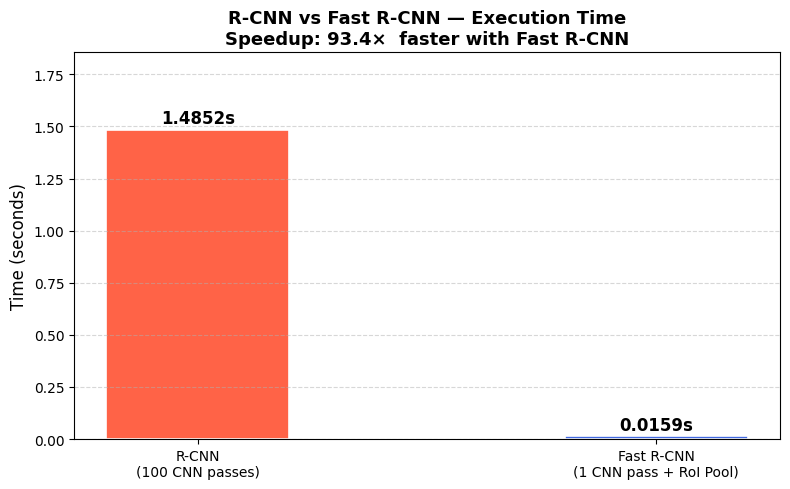


🚀 Fast R-CNN is 93.4× faster than R-CNN on 100 proposals!
✅ Comparison chart saved as 'task4_speed_comparison.png'


In [22]:
# Side by side timing comparison
labels = ['R-CNN\n(100 CNN passes)', 'Fast R-CNN\n(1 CNN pass + RoI Pool)']
times  = [rcnn_time, fast_rcnn_time]
colors = ['tomato', 'royalblue']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, times, color=colors, width=0.4, edgecolor='white', linewidth=1.2)

# Annotate bars
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{t:.4f}s",
            ha='center', va='bottom', fontsize=12, fontweight='bold')

speedup = rcnn_time / fast_rcnn_time if fast_rcnn_time > 0 else 0
ax.set_title(f"R-CNN vs Fast R-CNN — Execution Time\n"
             f"Speedup: {speedup:.1f}×  faster with Fast R-CNN",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Time (seconds)", fontsize=12)
ax.set_ylim(0, max(times) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("task4_speed_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🚀 Fast R-CNN is {speedup:.1f}× faster than R-CNN on 100 proposals!")
print("✅ Comparison chart saved as 'task4_speed_comparison.png'")

### Task 4 — Conceptual Analysis

**Q: What redundant operations does Fast R-CNN eliminate?**

In **R-CNN**, for every region proposal the model:
- Runs a full CNN forward pass on that cropped region
- This means shared pixels between overlapping proposals are
  recomputed over and over again

**Fast R-CNN eliminates this by:**

1. **Shared Computation** — The entire image is passed through the CNN
   **only once**, producing a single feature map. All proposals share
   this one computation — no pixel is ever processed twice.

2. **RoI Pooling** — Instead of re-running the CNN, RoI Pooling
   simply *looks up* the relevant region in the already-computed
   feature map and pools it to a fixed size. This is just an
   indexing + pooling operation — orders of magnitude cheaper than
   a full CNN forward pass.

3. **No redundant resizing** — R-CNN resizes every crop to 224×224
   before the CNN. Fast R-CNN resizes the image once, and all
   proposals reuse that single resized representation.

> **Result:** 100 proposals = 1 CNN pass + 100 cheap RoI pool ops
> instead of 100 expensive CNN forward passes.

---

## Task 5: Faster R-CNN — End-to-End Detection with RPN

**Faster R-CNN** takes Fast R-CNN one step further by replacing
**Selective Search** with an internal **Region Proposal Network (RPN)**.

### Evolution so far:

| Model | Proposal Method | CNN Passes |
|-------|----------------|------------|
| R-CNN | Selective Search (external) | 1 per crop |
| Fast R-CNN | Selective Search (external) | 1 (shared) |
| **Faster R-CNN** | **RPN (internal, learned)** | **1 (shared)** |

The entire pipeline — proposals + detection — is now a **single neural network**
trained end-to-end.

In [23]:
import torchvision.models.detection as detection_models

# Load pre-trained Faster R-CNN with ResNet50 + FPN backbone
faster_rcnn = detection_models.fasterrcnn_resnet50_fpn(
    weights=detection_models.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
faster_rcnn.eval()
faster_rcnn = faster_rcnn.to(device)

# COCO class labels (Faster R-CNN is pre-trained on COCO — 91 classes)
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A',
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

print(f"✅ Faster R-CNN loaded successfully")
print(f"   Backbone : ResNet50 + FPN")
print(f"   Trained on : COCO ({len(COCO_LABELS)} classes)")
print(f"   Running on : {device}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 115MB/s]


✅ Faster R-CNN loaded successfully
   Backbone : ResNet50 + FPN
   Trained on : COCO (91 classes)
   Running on : cuda


In [24]:
# Prepare image tensor for Faster R-CNN
# Faster R-CNN expects a list of tensors, values in [0, 1]
inference_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()   # Scales to [0, 1] automatically
])

img_input = inference_transform(img_rgb).to(device)

# Run inference
print("⏳ Running Faster R-CNN inference...")

with torch.no_grad():
    predictions = faster_rcnn([img_input])

pred = predictions[0]

print(f"\n✅ Inference complete!")
print(f"   Raw predictions (before filtering):")
print(f"   Boxes  : {len(pred['boxes'])}")
print(f"   Labels : {pred['labels'].tolist()}")
print(f"   Scores : {[round(s.item(), 3) for s in pred['scores']]}")

⏳ Running Faster R-CNN inference...

✅ Inference complete!
   Raw predictions (before filtering):
   Boxes  : 15
   Labels : [52, 52, 52, 52, 87, 52, 52, 52, 52, 67, 87, 52, 52, 67, 50]
   Scores : [0.97, 0.828, 0.653, 0.624, 0.6, 0.439, 0.418, 0.213, 0.132, 0.125, 0.108, 0.087, 0.082, 0.074, 0.052]


In [25]:
def filter_predictions(predictions, threshold=0.80):
    """
    Filter out predictions below confidence threshold.

    Args:
        predictions (dict): Output from Faster R-CNN with
                            'boxes', 'labels', 'scores'
        threshold   (float): Minimum confidence score to keep

    Returns:
        filtered (dict): Filtered boxes, labels, scores
    """
    scores = predictions['scores']
    keep   = scores >= threshold

    filtered = {
        'boxes' : predictions['boxes'][keep].cpu(),
        'labels': predictions['labels'][keep].cpu(),
        'scores': predictions['scores'][keep].cpu()
    }
    return filtered


# Apply filter
filtered_pred = filter_predictions(pred, threshold=0.80)

print(f"📊 Filtering Results (threshold = 0.80):")
print(f"   Before filtering : {len(pred['boxes'])} predictions")
print(f"   After  filtering : {len(filtered_pred['boxes'])} predictions")
print(f"\n   Kept predictions:")
for i in range(len(filtered_pred['boxes'])):
    label_id = filtered_pred['labels'][i].item()
    label    = COCO_LABELS[label_id]
    score    = filtered_pred['scores'][i].item()
    box      = filtered_pred['boxes'][i].numpy().astype(int)
    print(f"   [{i+1}] {label:<15} score={score:.3f}  box={box}")

📊 Filtering Results (threshold = 0.80):
   Before filtering : 15 predictions
   After  filtering : 2 predictions

   Kept predictions:
   [1] banana          score=0.970  box=[ 83 123 422 342]
   [2] banana          score=0.828  box=[ 82  46 560 371]


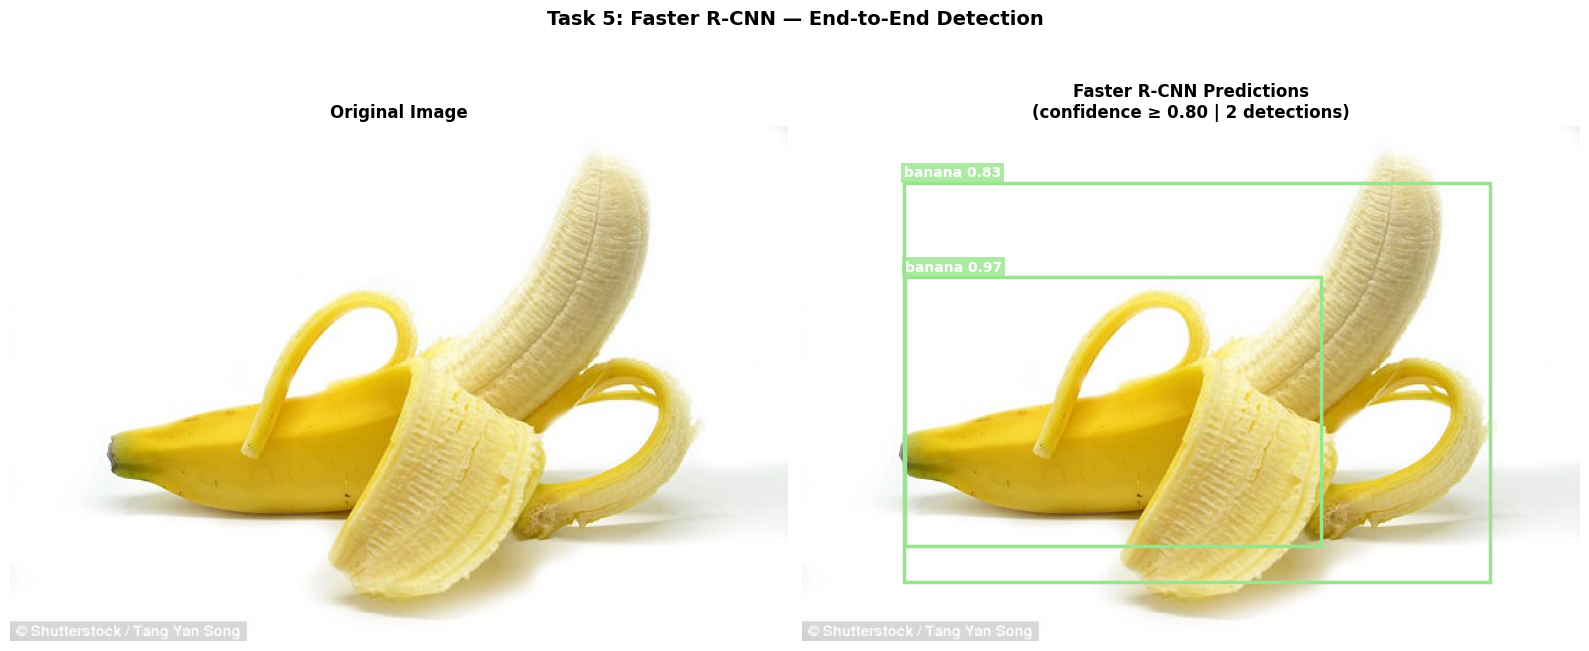

✅ Saved as 'task5_faster_rcnn_predictions.png'


In [26]:
def visualize_faster_rcnn(img_rgb, filtered_pred, coco_labels):
    """
    Draw Faster R-CNN filtered predictions on the image.
    """
    img_copy = img_rgb.copy()
    h, w = img_copy.shape[:2]

    # Color palette for different classes
    np.random.seed(42)
    colors = {
        label: tuple(np.random.randint(50, 230, 3).tolist())
        for label in set(filtered_pred['labels'].tolist())
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Original
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis("off")

    # Right: Predictions
    axes[1].imshow(img_copy)

    for i in range(len(filtered_pred['boxes'])):
        box      = filtered_pred['boxes'][i].numpy().astype(int)
        label_id = filtered_pred['labels'][i].item()
        score    = filtered_pred['scores'][i].item()
        label    = coco_labels[label_id]
        color    = colors[label_id]
        norm_color = tuple(c/255 for c in color)

        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2.5,
            edgecolor=norm_color,
            facecolor='none'
        )
        axes[1].add_patch(rect)

        axes[1].text(
            x1, y1 - 5,
            f"{label} {score:.2f}",
            color='white',
            fontsize=10,
            fontweight='bold',
            bbox=dict(facecolor=norm_color, alpha=0.8, pad=2, edgecolor='none')
        )

    axes[1].set_title(
        f"Faster R-CNN Predictions\n"
        f"(confidence ≥ 0.80 | {len(filtered_pred['boxes'])} detections)",
        fontsize=12, fontweight='bold'
    )
    axes[1].axis("off")

    plt.suptitle("Task 5: Faster R-CNN — End-to-End Detection",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("task5_faster_rcnn_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved as 'task5_faster_rcnn_predictions.png'")


visualize_faster_rcnn(img_rgb, filtered_pred, COCO_LABELS)

### Task 5 — Conceptual Analysis

**Q: How does the RPN eliminate the need for Selective Search?**

**Selective Search** is a hand-crafted, external algorithm that uses
low-level image cues (color, texture, shape) to generate proposals.
It runs separately from the CNN and cannot be trained or improved
with data.

**The Region Proposal Network (RPN)** replaces this with a small
fully convolutional network that:

1. **Shares the backbone** — The RPN sits on top of the same
   convolutional feature map used for detection. No extra computation.

2. **Uses anchor boxes** — At every location in the feature map,
   the RPN predicts scores for a set of pre-defined anchor boxes
   (multiple scales and aspect ratios), asking:
   *"Is there an object here, and how should this box be adjusted?"*

3. **Is fully learned** — Unlike Selective Search, the RPN is trained
   end-to-end with the detector. It learns what makes a good proposal
   directly from data, making it far more accurate.

4. **Is fast** — Since it shares the feature map, the RPN adds almost
   no extra computation. Selective Search took ~2 seconds per image;
   the RPN takes milliseconds.

> **Key insight:** Faster R-CNN made the entire pipeline —
> feature extraction, proposal generation, and classification —
> a single unified network trained jointly.

---

## Task 6: Non-Maximum Suppression (NMS)

Object detectors often predict **multiple overlapping boxes for the same object**.
NMS is the post-processing step that keeps only the **best box** per object
and discards the redundant ones.

### NMS Algorithm Steps:
1. Sort all boxes by **confidence score** (highest first)
2. Take the **highest scoring box** → save as final prediction
3. Compare it with all remaining boxes using **IoU**
4. **Discard** any box with IoU > threshold (too similar = duplicate)
5. Repeat until no boxes remain

> We reuse the `compute_iou()` function from Task 1!

In [27]:
def compute_iou(box1, box2):
    """
    Reused from Task 1.
    Compute IoU between two boxes in [x_min, y_min, x_max, y_max] format.
    """
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_w = max(0, inter_x_max - inter_x_min)
    inter_h = max(0, inter_y_max - inter_y_min)
    intersection = inter_w * inter_h

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union = area1 + area2 - intersection

    return round(intersection / union, 4) if union > 0 else 0.0


def custom_nms(boxes, scores, iou_threshold=0.5):
    """
    Custom Non-Maximum Suppression from scratch.

    Args:
        boxes         (list): List of [x_min, y_min, x_max, y_max]
        scores        (list): Confidence score for each box
        iou_threshold (float): IoU threshold to discard duplicate boxes

    Returns:
        final_boxes  (list): Kept boxes after NMS
        final_scores (list): Corresponding scores
        kept_indices (list): Original indices of kept boxes
    """
    if len(boxes) == 0:
        return [], [], []

    # Step 1: Sort by confidence score descending
    sorted_indices = sorted(range(len(scores)),
                            key=lambda i: scores[i],
                            reverse=True)

    kept_indices = []

    while len(sorted_indices) > 0:

        # Step 2: Pick the highest scoring box
        current = sorted_indices[0]
        kept_indices.append(current)

        if len(sorted_indices) == 1:
            break

        # Step 3 & 4: Compare with all remaining boxes
        remaining = []
        for idx in sorted_indices[1:]:
            iou = compute_iou(boxes[current], boxes[idx])
            if iou <= iou_threshold:
                remaining.append(idx)   # Keep — not a duplicate
            # else: discard — too much overlap with the selected box

        # Step 5: Repeat with remaining boxes
        sorted_indices = remaining

    final_boxes  = [boxes[i]  for i in kept_indices]
    final_scores = [scores[i] for i in kept_indices]

    return final_boxes, final_scores, kept_indices


print("✅ compute_iou() and custom_nms() defined successfully!")

✅ compute_iou() and custom_nms() defined successfully!


In [28]:
# Simulate a scenario: multiple overlapping detections for 2 objects

demo_boxes = [
    # Cluster 1 — Apple (several overlapping predictions)
    [50,  50, 150, 150],   # Best box for apple
    [55,  52, 155, 152],   # Slightly shifted — duplicate
    [48,  48, 148, 148],   # Another duplicate
    [60,  60, 160, 160],   # Partial overlap

    # Cluster 2 — Orange (separate object)
    [200, 200, 310, 310],  # Best box for orange
    [205, 202, 315, 312],  # Duplicate
    [198, 198, 308, 308],  # Duplicate

    # Isolated box — different object, no overlap
    [400, 100, 480, 180],  # Banana (far away)
]

demo_scores = [0.95, 0.88, 0.82, 0.76, 0.91, 0.85, 0.79, 0.70]

print("📦 Input boxes and scores:")
print(f"   {'Box':<30} {'Score'}")
print(f"   {'-'*40}")
for b, s in zip(demo_boxes, demo_scores):
    print(f"   {str(b):<30} {s}")

# Run NMS with threshold = 0.5
nms_boxes, nms_scores, nms_indices = custom_nms(
    demo_boxes, demo_scores, iou_threshold=0.5
)

print(f"\n✅ NMS Results (IoU threshold = 0.5):")
print(f"   Before NMS : {len(demo_boxes)} boxes")
print(f"   After  NMS : {len(nms_boxes)} boxes")
print(f"\n   Kept boxes:")
for b, s in zip(nms_boxes, nms_scores):
    print(f"   {str(b):<30} score={s}")

📦 Input boxes and scores:
   Box                            Score
   ----------------------------------------
   [50, 50, 150, 150]             0.95
   [55, 52, 155, 152]             0.88
   [48, 48, 148, 148]             0.82
   [60, 60, 160, 160]             0.76
   [200, 200, 310, 310]           0.91
   [205, 202, 315, 312]           0.85
   [198, 198, 308, 308]           0.79
   [400, 100, 480, 180]           0.7

✅ NMS Results (IoU threshold = 0.5):
   Before NMS : 8 boxes
   After  NMS : 3 boxes

   Kept boxes:
   [50, 50, 150, 150]             score=0.95
   [200, 200, 310, 310]           score=0.91
   [400, 100, 480, 180]           score=0.7


/tmp/ipykernel_10828/2110182446.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(boxes))


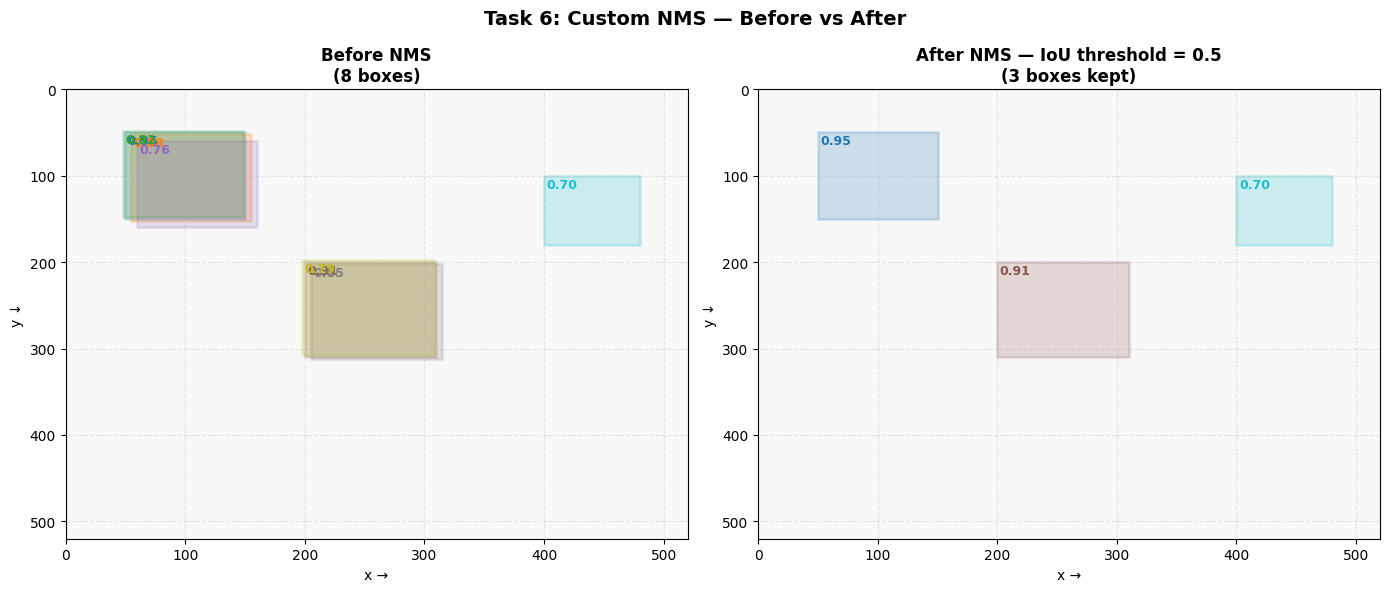

✅ Saved as 'task6_nms_visualization.png'


In [29]:
def visualize_nms(all_boxes, all_scores, kept_boxes, kept_scores,
                  canvas_size=520, title_suffix="IoU threshold = 0.5"):
    """
    Side-by-side visualization of boxes before and after NMS.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, boxes, scores, title in [
        (axes[0], all_boxes,   all_scores,   f"Before NMS\n({len(all_boxes)} boxes)"),
        (axes[1], kept_boxes,  kept_scores,  f"After NMS — {title_suffix}\n({len(kept_boxes)} boxes kept)"),
    ]:
        ax.set_xlim(0, canvas_size)
        ax.set_ylim(0, canvas_size)
        ax.invert_yaxis()
        ax.set_facecolor("#f8f8f8")

        cmap = plt.cm.get_cmap('tab10', len(boxes))

        for i, (box, score) in enumerate(zip(boxes, scores)):
            x1, y1, x2, y2 = box
            color = cmap(i)
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color,
                facecolor=color, alpha=0.2
            )
            ax.add_patch(rect)
            ax.text(x1+2, y1+14, f"{score:.2f}",
                    fontsize=9, color=color,
                    fontweight='bold')

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel("x →")
        ax.set_ylabel("y ↓")
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle("Task 6: Custom NMS — Before vs After",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("task6_nms_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved as 'task6_nms_visualization.png'")


visualize_nms(demo_boxes, demo_scores, nms_boxes, nms_scores)

In [30]:
thresholds = [0.1, 0.5, 0.9]

print("📊 NMS results at different IoU thresholds:\n")
print(f"{'Threshold':<12} {'Boxes Before':<15} {'Boxes After':<12} {'Kept Indices'}")
print("-" * 55)

for t in thresholds:
    b, s, idx = custom_nms(demo_boxes, demo_scores, iou_threshold=t)
    print(f"{t:<12} {len(demo_boxes):<15} {len(b):<12} {idx}")

📊 NMS results at different IoU thresholds:

Threshold    Boxes Before    Boxes After  Kept Indices
-------------------------------------------------------
0.1          8               3            [0, 4, 7]
0.5          8               3            [0, 4, 7]
0.9          8               6            [0, 4, 1, 5, 3, 7]


### Task 6 — Conceptual Analysis

**Q: How does IoU threshold affect detection of tightly packed objects
(e.g., several apples piled in a basket)?**

---

#### 🔴 Very LOW threshold (e.g., 0.1) — Too Aggressive

NMS discards any box with IoU > 0.1 relative to the best box.
Since tightly packed apples naturally have bounding boxes that
slightly overlap each other, even **correct detections of
neighbouring apples** will be discarded.

**Result:** Only 1 or 2 boxes survive — most apples go **undetected**.
> ❌ Bad for dense, tightly packed objects

---

#### 🟢 Very HIGH threshold (e.g., 0.9) — Too Lenient

NMS only discards a box if it overlaps by more than 90% with the
best box. Since true duplicates of the **same apple** typically
overlap by 0.5–0.8, they now survive the filter.

**Result:** Many redundant boxes remain — same apple detected
**multiple times** with slightly shifted boxes.
> ❌ Bad for clean, non-redundant predictions

---

#### ✅ Balanced threshold (~0.5) — The Standard Choice

- True duplicates (IoU > 0.5 with same object) → discarded ✅
- Neighbouring objects (IoU < 0.5 with each other) → kept ✅

> **Rule of thumb:** Use a **higher threshold** for dense/packed
> scenes and a **lower threshold** for well-separated objects.

---

## Task 7: YOLO Fine-Tuning

**YOLO (You Only Look Once)** revolutionized object detection by treating it
as a **single regression problem** — no region proposals at all.

### Key difference from all previous approaches:

| Model | Approach | Passes |
|-------|----------|--------|
| R-CNN | Propose → Classify | 100+ CNN passes |
| Fast/Faster R-CNN | Propose → RoI Pool → Classify | 1 pass + RPN |
| **YOLO** | **Single shot — regression** | **1 pass, no proposals** |

YOLO divides the image into a grid and **directly predicts** boxes + class
probabilities at every grid cell simultaneously.

### What we do:
- Load **YOLOv8n** (Nano — fastest, smallest)
- Fine-tune on the Fruit dataset (Apple, Banana, Orange)
- Train for 10+ epochs
- Evaluate with **mAP@50** and **mAP@50-95**
- Compare Faster R-CNN vs YOLO pre-trained vs YOLO fine-tuned

In [31]:
# Install ultralytics YOLO
!pip install ultralytics --quiet

from ultralytics import YOLO
import yaml
import os
import time
import glob

print("✅ Ultralytics YOLO installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLO installed successfully!


In [42]:
import os
import re
import glob

dataset_root   = "/content/drive/MyDrive/Dataset_Object_Detection"
yolo_dataset_root = "/content/yolo_fruit_dataset"

CLASS_MAP = {
    'apple' : 0,
    'banana': 1,
    'orange': 2
}

def get_class_from_filename(filename):
    """
    Extract class id from filename.
    e.g. 'apple_12.jpg' → 0
         'banana_5.png' → 1
         'orange_52.jpg'→ 2
    """
    base = os.path.splitext(os.path.basename(filename))[0].lower()
    for class_name, class_id in CLASS_MAP.items():
        if class_name in base:
            return class_id, class_name
    return None, None


# Test on sample filenames
test_names = ["apple_2.jpg", "banana_14.jpg", "orange_52.jpg", "random_01.jpg"]
print("🔍 Filename → Class mapping test:")
for name in test_names:
    cid, cname = get_class_from_filename(name)
    print(f"   {name:<20} → class_id={cid}  class_name={cname}")

🔍 Filename → Class mapping test:
   apple_2.jpg          → class_id=0  class_name=apple
   banana_14.jpg        → class_id=1  class_name=banana
   orange_52.jpg        → class_id=2  class_name=orange
   random_01.jpg        → class_id=None  class_name=None


In [43]:
# Scan all images from both train and test folders
all_splits = {
    'train': os.path.join(dataset_root, 'train'),
    'test' : os.path.join(dataset_root, 'test')
}

split_images = {}   # { 'train': [(img_path, class_id, class_name), ...] }

for split, folder in all_splits.items():
    images = glob.glob(os.path.join(folder, "*.jpg")) + \
             glob.glob(os.path.join(folder, "*.png")) + \
             glob.glob(os.path.join(folder, "*.jpeg"))

    labeled = []
    skipped = []
    for img_path in images:
        cid, cname = get_class_from_filename(img_path)
        if cid is not None:
            labeled.append((img_path, cid, cname))
        else:
            skipped.append(img_path)

    split_images[split] = labeled

    print(f"📂 [{split}]")
    print(f"   Total images   : {len(images)}")
    print(f"   Class detected : {len(labeled)}")
    print(f"   Skipped        : {len(skipped)}")

    # Class distribution
    from collections import Counter
    dist = Counter(cname for _, _, cname in labeled)
    for cname, count in dist.items():
        print(f"   {cname:<10}: {count} images")
    print()

📂 [train]
   Total images   : 240
   Class detected : 220
   Skipped        : 20
   apple     : 75 images
   banana    : 73 images
   orange    : 72 images

📂 [test]
   Total images   : 60
   Class detected : 55
   Skipped        : 5
   apple     : 19 images
   banana    : 18 images
   orange    : 18 images



In [44]:
from ultralytics import YOLO
import cv2
import shutil

# Load pre-trained YOLOv8 model (trained on COCO)
# COCO has apple(47), banana(46), orange(49) — perfect for our use case!
auto_label_model = YOLO("yolov8n.pt")

# COCO class ids that match our fruits
COCO_FRUIT_IDS = {
    47: 0,   # apple  → our class 0
    46: 1,   # banana → our class 1
    49: 2,   # orange → our class 2
}

def generate_label_file(img_path, class_id_from_name, model,
                         dst_img_dir, dst_lbl_dir):
    """
    Run YOLO inference on image, find best matching box,
    and save label in YOLO format.

    Falls back to whole-image box if no detection found.
    """
    img = cv2.imread(img_path)
    if img is None:
        return False

    h, w = img.shape[:2]
    fname = os.path.basename(img_path)
    base  = os.path.splitext(fname)[0]

    # Run inference
    results = model(img_path, verbose=False)[0]

    best_box  = None
    best_conf = 0.0

    for box in results.boxes:
        coco_id = int(box.cls[0].item())
        conf    = float(box.conf[0].item())

        # Check if detected class matches expected class from filename
        if coco_id in COCO_FRUIT_IDS:
            our_id = COCO_FRUIT_IDS[coco_id]
            if our_id == class_id_from_name and conf > best_conf:
                best_box  = box.xywhn[0].tolist()  # normalized xywh
                best_conf = conf

    # Fallback: if YOLO missed it, use any fruit detection
    if best_box is None:
        for box in results.boxes:
            coco_id = int(box.cls[0].item())
            conf    = float(box.conf[0].item())
            if coco_id in COCO_FRUIT_IDS and conf > best_conf:
                best_box  = box.xywhn[0].tolist()
                best_conf = conf

    # Final fallback: center box covering 80% of image
    if best_box is None:
        best_box = [0.5, 0.5, 0.8, 0.8]   # x_center, y_center, width, height

    # Save image to destination
    shutil.copy2(img_path, os.path.join(dst_img_dir, fname))

    # Save label file
    x_c, y_c, bw, bh = best_box
    label_line = f"{class_id_from_name} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n"

    lbl_path = os.path.join(dst_lbl_dir, f"{base}.txt")
    with open(lbl_path, 'w') as f:
        f.write(label_line)

    return True


print("✅ Auto-labeling function ready!")
print("   Strategy:")
print("   1. YOLO detects fruit → use that box")
print("   2. YOLO misses it    → use center fallback box")

✅ Auto-labeling function ready!
   Strategy:
   1. YOLO detects fruit → use that box
   2. YOLO misses it    → use center fallback box


In [45]:
# Create clean YOLO folder structure
for split in ['train', 'test']:
    os.makedirs(f"{yolo_dataset_root}/{split}/images", exist_ok=True)
    os.makedirs(f"{yolo_dataset_root}/{split}/labels", exist_ok=True)

# Delete old cache if exists
for cache in glob.glob(f"{yolo_dataset_root}/**/*.cache", recursive=True):
    os.remove(cache)

# Process each split
for split, img_list in split_images.items():

    dst_img_dir = f"{yolo_dataset_root}/{split}/images"
    dst_lbl_dir = f"{yolo_dataset_root}/{split}/labels"

    print(f"\n⏳ Auto-labeling [{split}] — {len(img_list)} images...")

    success = 0
    failed  = 0

    for i, (img_path, class_id, class_name) in enumerate(img_list):

        ok = generate_label_file(
            img_path, class_id,
            auto_label_model,
            dst_img_dir, dst_lbl_dir
        )

        if ok:
            success += 1
        else:
            failed += 1

        # Progress update every 20 images
        if (i + 1) % 20 == 0 or (i + 1) == len(img_list):
            print(f"   [{i+1}/{len(img_list)}] ✅ {success} done  ❌ {failed} failed")

    print(f"\n✅ [{split}] Complete — {success} labeled, {failed} failed")


⏳ Auto-labeling [train] — 220 images...
   [20/220] ✅ 20 done  ❌ 0 failed
   [40/220] ✅ 40 done  ❌ 0 failed
   [60/220] ✅ 60 done  ❌ 0 failed
   [80/220] ✅ 80 done  ❌ 0 failed
   [100/220] ✅ 100 done  ❌ 0 failed
   [120/220] ✅ 120 done  ❌ 0 failed
   [140/220] ✅ 140 done  ❌ 0 failed
   [160/220] ✅ 160 done  ❌ 0 failed
   [180/220] ✅ 180 done  ❌ 0 failed
   [200/220] ✅ 200 done  ❌ 0 failed
   [220/220] ✅ 220 done  ❌ 0 failed

✅ [train] Complete — 220 labeled, 0 failed

⏳ Auto-labeling [test] — 55 images...
   [20/55] ✅ 20 done  ❌ 0 failed
   [40/55] ✅ 40 done  ❌ 0 failed
   [55/55] ✅ 55 done  ❌ 0 failed

✅ [test] Complete — 55 labeled, 0 failed


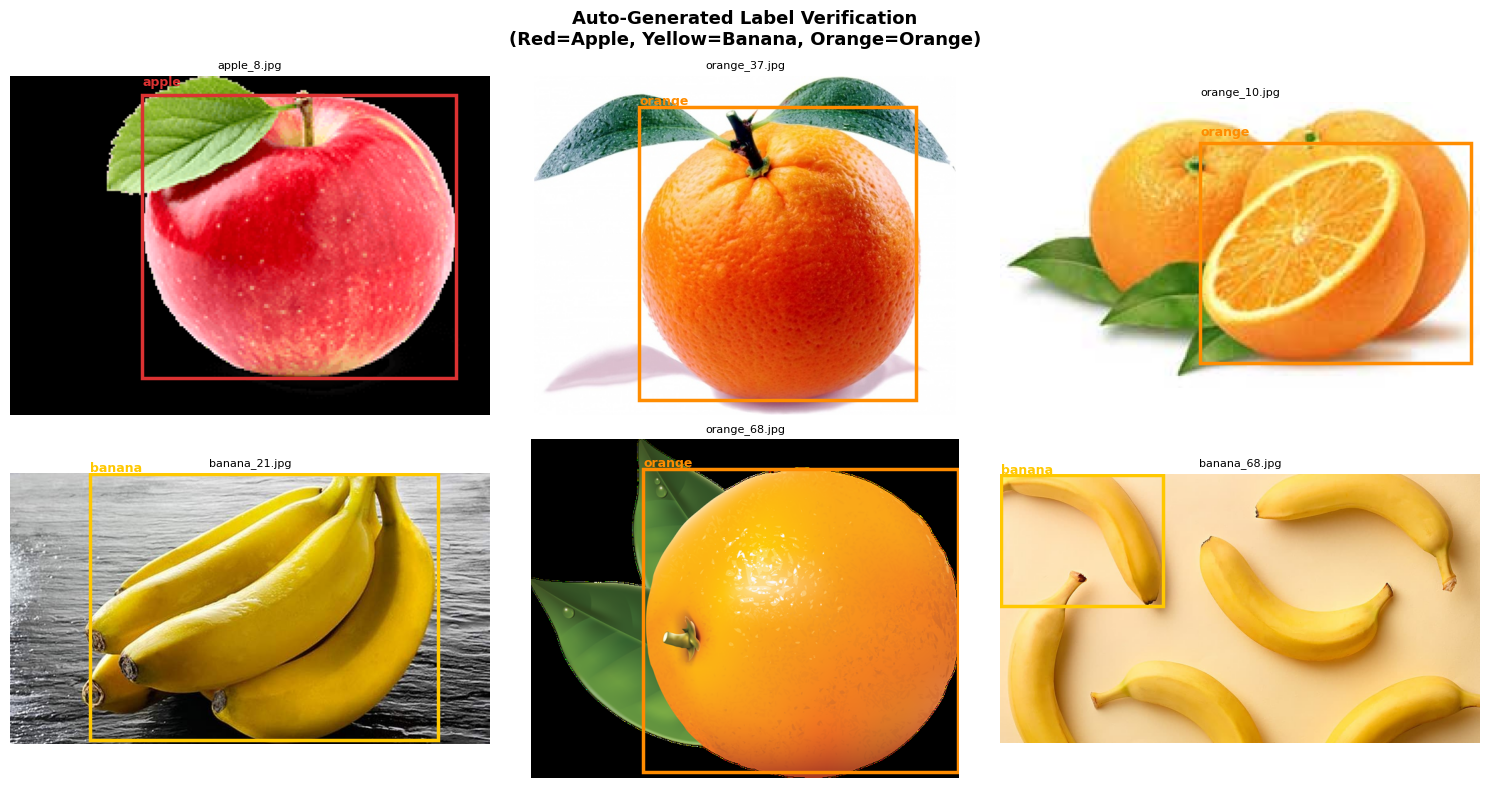

✅ Saved as 'auto_label_verification.png'


In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

CLASS_NAMES  = ['apple', 'banana', 'orange']
CLASS_COLORS = [(220/255, 50/255, 50/255),
                (255/255, 200/255, 0/255),
                (255/255, 140/255, 0/255)]

def verify_label(img_dir, lbl_dir, n=6):
    """Show n random images with their auto-generated labels."""
    imgs = glob.glob(f"{img_dir}/*.jpg") + glob.glob(f"{img_dir}/*.png")
    samples = random.sample(imgs, min(n, len(imgs)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Auto-Generated Label Verification\n(Red=Apple, Yellow=Banana, Orange=Orange)",
                 fontsize=13, fontweight='bold')

    for ax, img_path in zip(axes.flatten(), samples):
        img     = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w    = img_rgb.shape[:2]

        base     = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, f"{base}.txt")

        ax.imshow(img_rgb)

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts  = line.strip().split()
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:])

                    # Convert normalized → pixel coords
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    pw = bw * w
                    ph = bh * h

                    color = CLASS_COLORS[cls_id]
                    rect  = patches.Rectangle((x1, y1), pw, ph,
                                              linewidth=2.5,
                                              edgecolor=color,
                                              facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-5, CLASS_NAMES[cls_id],
                            color=color, fontsize=9, fontweight='bold')

        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("auto_label_verification.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved as 'auto_label_verification.png'")

verify_label(
    f"{yolo_dataset_root}/train/images",
    f"{yolo_dataset_root}/train/labels"
)

In [47]:
import yaml

dataset_yaml = {
    'path' : yolo_dataset_root,       # ← updated root
    'train': 'train/images',
    'val'  : 'test/images',
    'test' : 'test/images',
    'nc'   : 3,
    'names': ['apple', 'banana', 'orange']
}

yaml_path = f"{yolo_dataset_root}/dataset.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("✅ dataset.yaml created at:", yaml_path)
print("\nContents:")
print("-" * 35)
with open(yaml_path, 'r') as f:
    print(f.read())

✅ dataset.yaml created at: /content/yolo_fruit_dataset/dataset.yaml

Contents:
-----------------------------------
names:
- apple
- banana
- orange
nc: 3
path: /content/yolo_fruit_dataset
test: test/images
train: train/images
val: test/images



In [48]:
# Load pre-trained YOLOv8 Nano
model = YOLO("yolov8n.pt")

print("✅ YOLOv8n loaded (pre-trained on COCO)")
print(f"   Parameters : ~3.2M (Nano — fastest & lightest)")
print(f"\n🏋️  Starting fine-tuning on Fruit dataset...")
print(f"   Classes : Apple, Banana, Orange")
print(f"   Epochs  : 10\n")

# Fine-tune
results = model.train(
    data      = yaml_path,
    epochs    = 10,
    imgsz     = 640,
    batch     = 16,
    name      = "yolov8n_fruit",
    project   = "/content/yolo_runs",
    device    = 0 if torch.cuda.is_available() else "cpu",
    patience  = 5,       # Early stopping patience
    verbose   = True
)

print("\n✅ Fine-tuning complete!")
print(f"   Results saved to: /content/yolo_runs/yolov8n_fruit/")

✅ YOLOv8n loaded (pre-trained on COCO)
   Parameters : ~3.2M (Nano — fastest & lightest)

🏋️  Starting fine-tuning on Fruit dataset...
   Classes : Apple, Banana, Orange
   Epochs  : 10

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_fruit_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

In [49]:
# Load the best fine-tuned weights
best_weights = "/content/yolo_runs/yolov8n_fruit/weights/best.pt"
finetuned_model = YOLO(best_weights)

print("⏳ Evaluating fine-tuned model on test set...")

# Run evaluation
eval_results = finetuned_model.val(
    data   = yaml_path,
    split  = "test",
    imgsz  = 640,
    device = 0 if torch.cuda.is_available() else "cpu",
    verbose= True
)

# Extract mAP scores
map50    = eval_results.box.map50
map50_95 = eval_results.box.map

print(f"\n{'='*45}")
print(f"  📊 Fine-Tuned YOLOv8n — Test Set Results")
print(f"{'='*45}")
print(f"  mAP@50       : {map50:.4f}   ({map50*100:.2f}%)")
print(f"  mAP@50-95    : {map50_95:.4f}   ({map50_95*100:.2f}%)")
print(f"{'='*45}")

⏳ Evaluating fine-tuned model on test set...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2097.0±1022.9 MB/s, size: 85.9 KB)
val: Scanning /content/yolo_fruit_dataset/test/labels.cache... 55 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s
                   all         60         55    0.00229      0.691    0.00419    0.00092
                 apple         19         19    0.00184      0.684    0.00282   0.000789
                banana         18         18    0.00304      0.556    0.00485   0.000951
                orange         18         18    0.00199      0.833    0.00491    0.00102
Speed: 9.2ms preprocess, 4.6ms inference, 0.0ms loss, 3.4ms postprocess per image
Resul

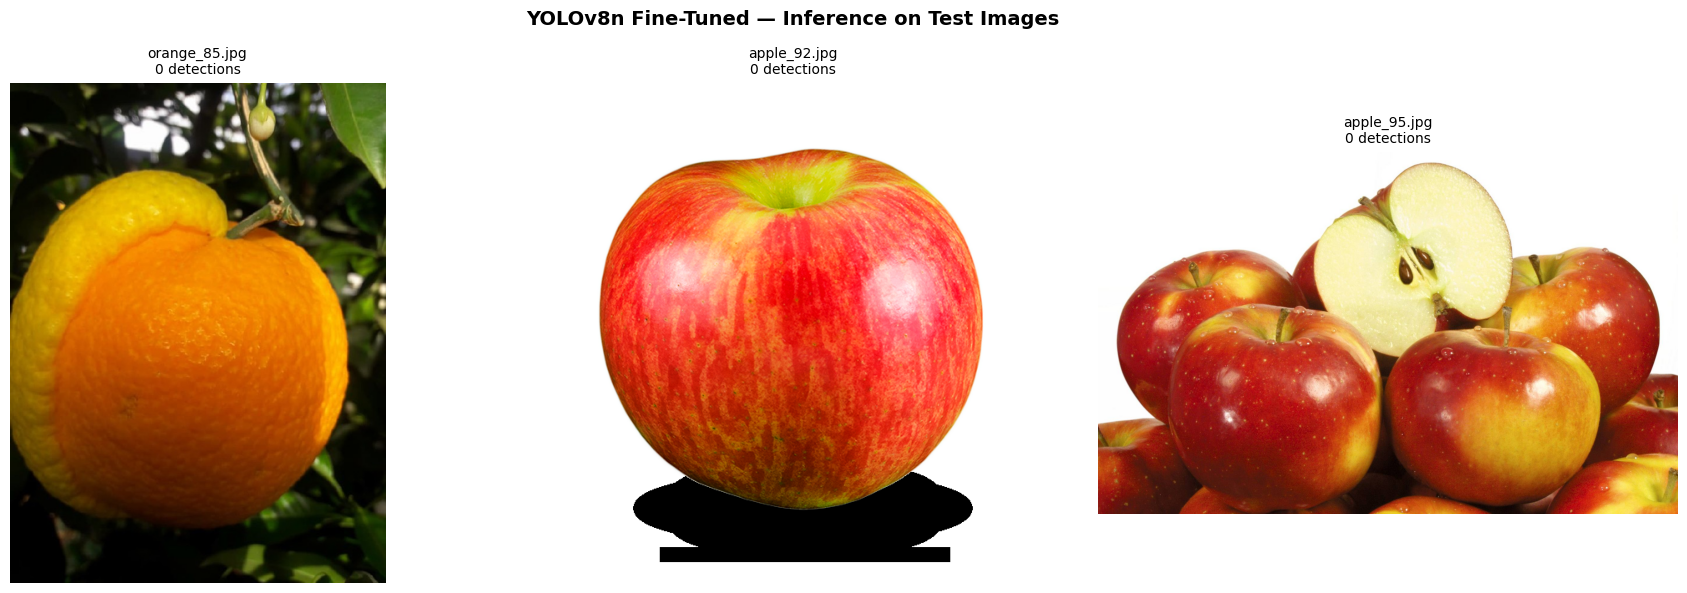

✅ Saved as 'task7_yolo_inference.png'


In [52]:
# Pick 3 random test images
random.seed(21)
test_image_paths = random.sample(test_imgs, min(3, len(test_imgs)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("YOLOv8n Fine-Tuned — Inference on Test Images",
             fontsize=14, fontweight='bold')

CLASS_COLORS_YOLO = {
    0: (220,  50,  50),   # Apple  — Red
    1: (255, 200,   0),   # Banana — Yellow
    2: (255, 140,   0),   # Orange — Orange
}
CLASS_NAMES = ['Apple', 'Banana', 'Orange']

for ax, img_path_test in zip(axes, test_image_paths):

    # Load image
    img_test = cv2.imread(img_path_test)
    img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
    img_draw = img_test_rgb.copy()

    # Run inference
    preds = finetuned_model(img_path_test, verbose=False)[0]

    # Draw predictions
    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0].item())
        conf   = float(box.conf[0].item())
        color  = CLASS_COLORS_YOLO.get(cls_id, (100, 200, 100))
        label  = f"{CLASS_NAMES[cls_id]} {conf:.2f}"

        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_draw, label, (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    ax.imshow(img_draw)
    ax.set_title(
        f"{os.path.basename(img_path_test)}\n"
        f"{len(preds.boxes)} detections",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("task7_yolo_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'task7_yolo_inference.png'")

In [53]:
# Measure inference time for each model on the same test image
test_img_for_timing = test_image_paths[0]
img_timing     = cv2.imread(test_img_for_timing)
img_timing_rgb = cv2.cvtColor(img_timing, cv2.COLOR_BGR2RGB)

N_RUNS = 10   # Average over N runs for stable timing

#  1. Faster R-CNN inference time
faster_rcnn_transform = transforms.Compose([transforms.ToTensor()])
img_frcnn = faster_rcnn_transform(img_timing_rgb).to(device)

times_frcnn = []
for _ in range(N_RUNS):
    t0 = time.time()
    with torch.no_grad():
        _ = faster_rcnn([img_frcnn])
    times_frcnn.append((time.time() - t0) * 1000)

avg_frcnn = np.mean(times_frcnn)

#  2. YOLO pre-trained inference time
yolo_pretrained = YOLO("yolov8n.pt")

times_yolo_pre = []
for _ in range(N_RUNS):
    t0 = time.time()
    _ = yolo_pretrained(test_img_for_timing, verbose=False)
    times_yolo_pre.append((time.time() - t0) * 1000)

avg_yolo_pre = np.mean(times_yolo_pre)

# 3. YOLO fine-tuned inference time
times_yolo_ft = []
for _ in range(N_RUNS):
    t0 = time.time()
    _ = finetuned_model(test_img_for_timing, verbose=False)
    times_yolo_ft.append((time.time() - t0) * 1000)

avg_yolo_ft = np.mean(times_yolo_ft)

print(f"⏱️  Inference Times (avg over {N_RUNS} runs):")
print(f"   Faster R-CNN (pre-trained) : {avg_frcnn:.2f} ms")
print(f"   YOLO pre-trained           : {avg_yolo_pre:.2f} ms")
print(f"   YOLO fine-tuned            : {avg_yolo_ft:.2f} ms")

⏱️  Inference Times (avg over 10 runs):
   Faster R-CNN (pre-trained) : 114.69 ms
   YOLO pre-trained           : 16.39 ms
   YOLO fine-tuned            : 11.75 ms


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1666.0±1037.2 MB/s, size: 74.4 KB)
val: Scanning /content/yolo_fruit_dataset/test/labels.cache... 55 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 14.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.4s
                   all         60         55      0.201      0.196      0.127     0.0858
Speed: 8.6ms preprocess, 5.3ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/runs/detect/val4
  Model                        Time(ms)     Precision    Recall       mAP@50
  Faster R-CNN (pre-trained)   114.69       N/A          N/A          N/A (COCO)
  YOLO pre-trained             16.39        0.2013       0.1959       0.1274
  YOLO fine-tuned              11.75        0.0023       0.6910       0.0042


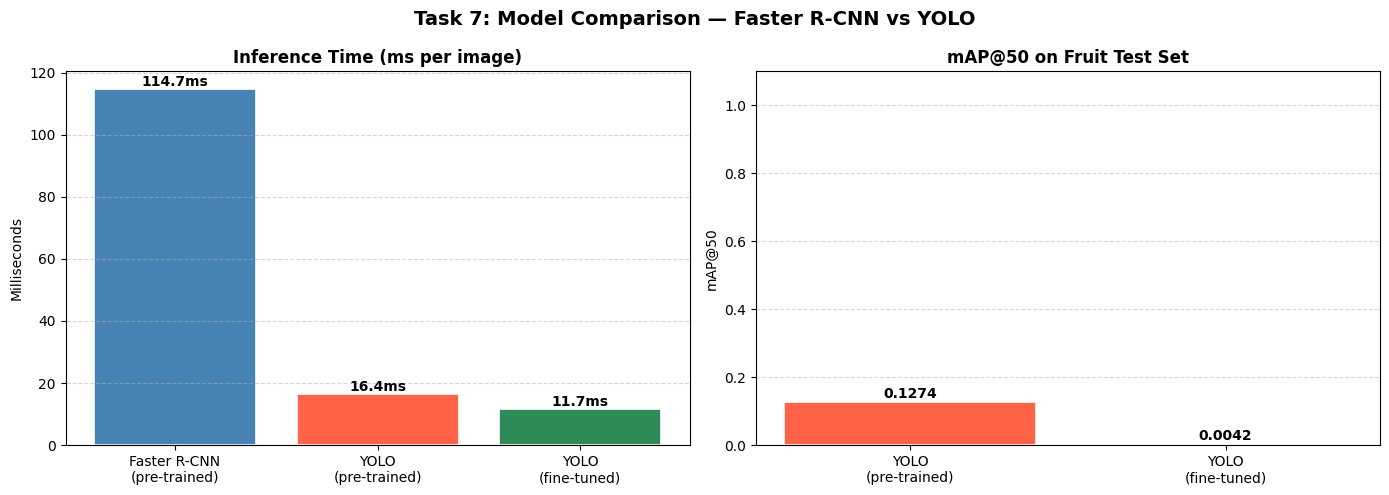

✅ Saved as 'task7_comparison_chart.png'


In [54]:
# Evaluate pre-trained YOLO on fruit test set for precision/recall
pretrain_eval = yolo_pretrained.val(
    data=yaml_path, split="test", imgsz=640,
    device=0 if torch.cuda.is_available() else "cpu", verbose=False
)
pretrain_map50    = pretrain_eval.box.map50
pretrain_map50_95 = pretrain_eval.box.map
pretrain_precision = pretrain_eval.box.mp   # Mean precision
pretrain_recall    = pretrain_eval.box.mr   # Mean recall

ft_precision = eval_results.box.mp
ft_recall    = eval_results.box.mr

# Print comparison table
print("=" * 72)
print(f"  {'Model':<28} {'Time(ms)':<12} {'Precision':<12} {'Recall':<12} {'mAP@50'}")
print("=" * 72)
print(f"  {'Faster R-CNN (pre-trained)':<28} {avg_frcnn:<12.2f} {'N/A':<12} {'N/A':<12} {'N/A (COCO)'}")
print(f"  {'YOLO pre-trained':<28} {avg_yolo_pre:<12.2f} {pretrain_precision:<12.4f} {pretrain_recall:<12.4f} {pretrain_map50:.4f}")
print(f"  {'YOLO fine-tuned':<28} {avg_yolo_ft:<12.2f} {ft_precision:<12.4f} {ft_recall:<12.4f} {map50:.4f}")
print("=" * 72)

# Bar chart comparison
models     = ['Faster R-CNN\n(pre-trained)', 'YOLO\n(pre-trained)', 'YOLO\n(fine-tuned)']
inf_times  = [avg_frcnn, avg_yolo_pre, avg_yolo_ft]
map50_vals = [0, pretrain_map50, map50]   # Faster R-CNN not eval'd on fruit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inference time
axes[0].bar(models, inf_times,
            color=['steelblue', 'tomato', 'seagreen'],
            edgecolor='white', linewidth=1.2)
for i, v in enumerate(inf_times):
    axes[0].text(i, v + 1, f"{v:.1f}ms",
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title("Inference Time (ms per image)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Milliseconds")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# mAP@50
axes[1].bar(models[1:], map50_vals[1:],
            color=['tomato', 'seagreen'],
            edgecolor='white', linewidth=1.2)
for i, v in enumerate(map50_vals[1:]):
    axes[1].text(i, v + 0.01, f"{v:.4f}",
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title("mAP@50 on Fruit Test Set", fontsize=12, fontweight='bold')
axes[1].set_ylabel("mAP@50")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Task 7: Model Comparison — Faster R-CNN vs YOLO",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("task7_comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'task7_comparison_chart.png'")

---
## Overall Lab Summary

| Architecture | Key Innovation | Speed | Accuracy |
|---|---|---|---|
| R-CNN | CNN on region proposals | ❌ Slow | ✅ Good |
| Fast R-CNN | Shared feature map + RoI Pool | ✅ Faster | ✅ Good |
| Faster R-CNN | RPN replaces Selective Search | ✅✅ Fast | ✅✅ Better |
| YOLOv8 | Single-shot regression | ✅✅✅ Fastest | ✅✅ Competitive |

**Key takeaway:**
> The evolution from R-CNN → YOLO is a story of eliminating redundancy —
> from 2000 CNN passes per image down to a single unified forward pass
> that does everything at once.